<div dir="rtl" style="text-align: right; font-size: 28px; font-weight: bold; background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 20px; border-radius: 10px; margin-bottom: 20px;">

# Week 8: Sequence Models (RNN, LSTM, GRU, BiRNN)

النهاردة هنطبقها على Text Classification بإذن الله!

</div>

## Overview

**Instructor:** Dr. Mahmoud Eid (m.eid@fci-cu.edu.eg)

**Estimated Time:** 3-4 hours

**What You'll Learn:**

**Part 1: Many-to-Many Sequence Classification (Food Entity Recognition)**

- Word-level classification (is each word food or not?)
- Tokenization and pre-trained word embeddings (GloVe)
- We will work with Vanilla RNN → GRU → LSTM → BiLSTM

**Part 2: Many-to-One Sequence Classification (Spam classification, PRACTICE)**


**Prerequisites:** PyTorch basics (Week 5+), Knowledge about text (Lecture 13 and Lecture 14)

---



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import accuracy_score, classification_report
from collections import Counter, defaultdict
from datasets import load_dataset
import random
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('dark_background')
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.9.0+cu126


---

<div dir="rtl" style="text-align: right; font-size: 22px; font-weight: bold; background-color: #1a1a2e; padding: 15px; border-radius: 10px;">

# Part 1: Many-to-Many (Food Entity Recognition)

</div>

**Task:** Given a sentence, classify **each word** as food (1) or not food (0)

**Example:**

- Sentence: `"I love eating pizza for dinner"`
- Labels: `[0, 0, 0, 1, 0, 0]` (only "pizza" is food)

This is **Named Entity Recognition (NER)** for food items!


## Step 1: Generate Food Entity Dataset

We'll create 1200 diverse sentences with 102 unique food items to ensure models **learn patterns** (not just memorize)!


In [2]:
# Food vocabulary (102 unique items across 9 categories)
food_items = {
    'proteins': ['chicken', 'beef', 'fish', 'salmon', 'tuna', 'turkey', 'lamb',
                 'shrimp', 'tofu', 'eggs', 'duck', 'crab', 'lobster'],
    'vegetables': ['carrot', 'broccoli', 'spinach', 'tomato', 'onion', 'garlic', 'pepper',
                   'lettuce', 'cucumber', 'potato', 'mushroom', 'celery', 'kale', 'zucchini',
                   'eggplant', 'avocado', 'beans', 'peas'],
    'fruits': ['apple', 'banana', 'orange', 'strawberry', 'blueberry', 'mango', 'pineapple',
               'grape', 'watermelon', 'lemon', 'lime', 'peach', 'cherry', 'kiwi', 'berries'],
    'grains': ['rice', 'pasta', 'bread', 'quinoa', 'oats', 'noodles', 'tortilla', 'bagel',
               'cereal', 'couscous', 'barley', 'crackers'],
    'dairy': ['milk', 'cheese', 'yogurt', 'butter', 'cream'],
    'beverages': ['coffee', 'tea', 'juice', 'water', 'soda', 'wine', 'beer', 'smoothie',
                  'latte', 'lemonade'],
    'dishes': ['pizza', 'burger', 'salad', 'soup', 'sandwich', 'curry', 'steak', 'sushi',
               'taco', 'burrito', 'ramen', 'lasagna', 'pie', 'omelet', 'pancakes'],
    'spices': ['salt', 'pepper', 'cinnamon', 'vanilla', 'oregano', 'basil', 'thyme', 'cumin',
               'paprika', 'ginger'],
    'sweets': ['chocolate', 'cake', 'cookie', 'candy', 'donut', 'brownie', 'muffin', 'pudding',
               'syrup', 'honey'],
}

all_foods = set([item for category in food_items.values() for item in category])
print(f"Total unique food items: {len(all_foods)}")
print(f"Sample foods: {list(all_foods)[:15]}")

Total unique food items: 107
Sample foods: ['beef', 'basil', 'apple', 'pancakes', 'paprika', 'beer', 'avocado', 'strawberry', 'cake', 'pineapple', 'barley', 'grape', 'butter', 'chocolate', 'lettuce']


In [3]:
# Sentence templates with diverse structures
templates = [
    "I love eating {food} for {meal}",
    "The restaurant serves delicious {food}",
    "She ordered {food} and {food} for dinner",
    "My favorite breakfast is {food} with {food}",
    "He drinks {beverage} every morning",
    "The chef prepared {food} with {food}",
    "Add some {spice} to the {food}",
    "I bought fresh {food} from the market",
    "The {food} tastes amazing with {spice}",
    "She prefers {beverage} over {beverage}",
    "The menu includes {food} and {food}",
    "We shared a large {food} last night",
    "Bake the {food} for thirty minutes",
    "Season with {spice} and {spice} generously",
    "Grill the {food} on high heat",
    "I need to buy {food} and {food}",
    "The bakery has fresh {food} daily",
    "My lunch includes {food} and chips",
    "The kids want {food} for lunch",
    "Dinner tonight is {food} with {food}",
    "Mix {food} and {spice} in a bowl",
    "The {food} was perfectly cooked",
    "She enjoys {beverage} with her meal",
    "The store sells organic {food}",
    "Top it with some {food}",
]

meals = ['breakfast', 'lunch', 'dinner', 'snack', 'brunch']


def generate_food_sentence():
    """Generate a random sentence with food entities"""
    template = random.choice(templates)
    sentence = template

    if '{meal}' in sentence:
        sentence = sentence.replace('{meal}', random.choice(meals))

    while '{food}' in sentence:
        category = random.choice(list(food_items.keys()))
        sentence = sentence.replace('{food}', random.choice(food_items[category]), 1)

    while '{beverage}' in sentence:
        sentence = sentence.replace('{beverage}', random.choice(food_items['beverages']), 1)

    while '{spice}' in sentence:
        sentence = sentence.replace('{spice}', random.choice(food_items['spices']), 1)

    # word-level labels
    words = sentence.lower().split()
    labels = [1 if word in all_foods else 0 for word in words]

    return words, labels


# Generate 1200 sentences
random.seed(42)
all_sentences = []
all_labels = []

for i in range(1200):
    words, labels = generate_food_sentence()
    all_sentences.append(words)
    all_labels.append(labels)

# note here how we are adding some samples that express a different meaning than food
# so that the models understand from the context that this is not food
challenging_context_cases = [
    # Animals (not food context)
    (["the", "chicken", "crossed", "the", "road"], [0, 0, 0, 0, 0]),
    (["i", "saw", "a", "turkey", "in", "the", "forest"], [0, 0, 0, 0, 0, 0, 0]),
    (["the", "fish", "are", "swimming", "in", "the", "lake"], [0, 0, 0, 0, 0, 0, 0]),
    (["she", "bought", "a", "duck", "for", "the", "pond"], [0, 0, 0, 0, 0, 0, 0]),
    (["the", "lamb", "is", "grazing", "in", "the", "field"], [0, 0, 0, 0, 0, 0, 0]),

    # Non-food compound words
    (["the", "coffee", "table", "is", "made", "of", "wood"], [0, 0, 0, 0, 0, 0, 0]),
    (["she", "opened", "a", "juice", "bar", "downtown"], [0, 0, 0, 0, 0, 0]),
    (["the", "pepper", "spray", "was", "very", "effective"], [0, 0, 0, 0, 0, 0]),
    (["he", "wore", "a", "chocolate", "brown", "jacket"], [0, 0, 0, 0, 0, 0]),
    (["the", "bread", "basket", "arrived", "empty"], [0, 0, 0, 0, 0]),
    (["the", "apple", "tree", "is", "blooming"], [0, 0, 0, 0, 0]),
    (["she", "has", "strawberry", "blonde", "hair"], [0, 0, 0, 0, 0]),
    (["the", "milk", "bottle", "is", "in", "recycling"], [0, 0, 0, 0, 0, 0]),
    (["the", "cheese", "grater", "is", "sharp"], [0, 0, 0, 0, 0]),

    # Food context (these are food)
    (["i", "love", "eating", "grilled", "chicken", "breast"], [0, 0, 0, 0, 1, 1]),
    (["she", "ordered", "fresh", "fish", "for", "dinner"], [0, 0, 0, 1, 0, 0]),
    (["the", "roasted", "duck", "was", "delicious"], [0, 0, 1, 0, 0]),
    (["i", "cooked", "lamb", "chops", "yesterday"], [0, 0, 1, 0, 0]),
    (["he", "drinks", "coffee", "every", "morning"], [0, 0, 1, 0, 0]),
    (["pour", "orange", "juice", "into", "the", "glass"], [0, 0, 1, 0, 0, 0]),
    (["she", "spread", "strawberry", "jam", "on", "toast"], [0, 0, 1, 1, 0, 1]),
    (["the", "apple", "pie", "smells", "amazing"], [0, 1, 1, 0, 0]),
    (["he", "bought", "fresh", "milk", "today"], [0, 0, 0, 1, 0]),
    (["grate", "some", "cheese", "on", "top"], [0, 0, 1, 0, 0]),
]

# adding challenging cases many times to training (so model learns them well)
# Repeat 10 times to emphasize these patterns
for _ in range(10):
    for sentence, labels in challenging_context_cases:
        all_sentences.append(sentence)
        all_labels.append(labels)

# Shuffle all data
combined = list(zip(all_sentences, all_labels))  # combined will be a list [ (sentence1, label1), (sentence2, label2), (sentence3, label3), ...]
# zip(sentences, labels) -> pairs row by row.
random.shuffle(combined)
all_sentences, all_labels = zip(*combined)  # we un-pack with * then re-zip across columns
# zip(*combined) -> transposes the list of pairs back into two separate lists/tuples (columns).
all_sentences = list(all_sentences)
all_labels = list(all_labels)

# Split: 80% train, 10% validation, 10% test
split_idx1 = int(0.8 * len(all_sentences)) #80
split_idx2 = int(0.9 * len(all_sentences)) #90

train_sentences = all_sentences[:split_idx1]
train_labels = all_labels[:split_idx1]
val_sentences = all_sentences[split_idx1:split_idx2]
val_labels = all_labels[split_idx1:split_idx2]
test_sentences = all_sentences[split_idx2:]
test_labels = all_labels[split_idx2:]

print(f"Generated {len(all_sentences)} total sentences (includes challenging cases repeated 10x for training)")
print(f"Train: {len(train_sentences)}, Validation: {len(val_sentences)}, Test: {len(test_sentences)}")
print(f"\n{'='*60}")
print("Sample challenging sentences (now part of training!):")
print("\n1. the chicken crossed the road")
print("   Labels: [0,0,0,0,0] (chicken = animal, NOT food)")
print("\n2. i love eating grilled chicken breast")
print("   Labels: [0,0,0,0,1,1] (chicken = food in this context)")
print("\n3. the coffee table is made of wood")
print("   Labels: [0,0,0,0,0,0,0] (coffee table = furniture)")
print("\n4. he drinks coffee every morning")
print("   Labels: [0,0,1,0,0] (coffee = beverage)")

Generated 1440 total sentences (includes challenging cases repeated 10x for training)
Train: 1152, Validation: 144, Test: 144

Sample challenging sentences (now part of training!):

1. the chicken crossed the road
   Labels: [0,0,0,0,0] (chicken = animal, NOT food)

2. i love eating grilled chicken breast
   Labels: [0,0,0,0,1,1] (chicken = food in this context)

3. the coffee table is made of wood
   Labels: [0,0,0,0,0,0,0] (coffee table = furniture)

4. he drinks coffee every morning
   Labels: [0,0,1,0,0] (coffee = beverage)


In [4]:
len(all_sentences)*0.8

1152.0

Before shuffle:
```python
all_sentences = ["I love this", "Bad movie", "Great film"]
all_labels = [1, 0, 1]
```
Step 1: `zip(all_sentences, all_labels)`
```python
combined = [("I love this", 1), ("Bad movie", 0), ("Great film", 1)]
# Pairs each sentence with its label
```
Step 2: After `random.shuffle(combined)`
```python
combined = [("Bad movie", 0), ("Great film", 1), ("I love this", 1)]
# Shuffled the pairs together
```
Step 3: `zip(*combined)` - unpacks them back
```python
# The * unpacks it, so it becomes:
zip(("Bad movie", 0), ("Great film", 1), ("I love this", 1))
# Now zip gets each tuple separately
all_sentences = ("Bad movie", "Great film", "I love this")
all_labels = (0, 1, 1)
# add them in list() function to make them as lists like all_labels = [0, 1, 1]
```

---

## Step 2: Build Vocabulary and Load Pre-trained Embeddings

We'll use **GloVe** (Global Vectors) embeddings trained on billions of words. This gives our models semantic understanding!


In [5]:
text = "Hi mohamed hi"
Counter(text.lower().split())

Counter({'hi': 2, 'mohamed': 1})

In [6]:
# Build vocabulary from training data
vocab = {'<PAD>': 0, '<UNK>': 1}
word_counts = Counter()

for sentence in train_sentences:
    word_counts.update(sentence)

# Add words that appear at least twice
for word, count in word_counts.items():
    if count >= 2 and word not in vocab:
        vocab[word] = len(vocab)

print(f"Vocabulary size: {len(vocab)}")
print(f"Sample vocab: {list(vocab.items())[:10]}")

# Reverse vocabulary (id -> word)
id2word = {idx: word for word, idx in vocab.items()}

Vocabulary size: 233
Sample vocab: [('<PAD>', 0), ('<UNK>', 1), ('the', 2), ('bakery', 3), ('has', 4), ('fresh', 5), ('brownie', 6), ('daily', 7), ('she', 8), ('prefers', 9)]


```
Why these special tokens?
<PAD> (padding) = 0
Neural networks need all sentences to be the same length in a batch
We add <PAD> to shorter sentences to match the longest one
Example: "I love ML" → "I love ML <PAD>"  (now 4 words)  -- Sentence 2: "Deep learning is amazing" (4 words)
As numbers: Sentence 1: [2, 3, 4, 0] ← the 0 is padding --- Sentence 2: [5, 6, 7, 8]

<UNK> (unknown) = 1
Handles words that are too rare (appear < 2 times) or never seen during training
Example: "I love robotics" → if "robotics" isn't in vocab, it becomes <UNK> → [2, 3, 1]
This prevents crashes and lets the model handle words it's never seen before.
```
---
```
vocab (word → number): Used to convert sentences into numbers for training
"I love ML" → [2, 3, 1] (ML becomes 1 because it's unknown)


id2word (number → word): Used to convert model predictions back to readable text
[2, 3] → "I love"

In [7]:
# note in here how i didn't give you the file but i uploaded it to my google drive
# so that you can download them to your colab machine
# glove_path = 'https://drive.google.com/file/d/1WTbdKo7sNTfvRim2Sxm_aSNn2sCibe1q/view?usp=sharing'
import gdown

# Google Drive file ID from my link
file_id = "1WTbdKo7sNTfvRim2Sxm_aSNn2sCibe1q"
url = f"https://drive.google.com/uc?id={file_id}"

output = "glove_vectors.txt"
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1WTbdKo7sNTfvRim2Sxm_aSNn2sCibe1q
From (redirected): https://drive.google.com/uc?id=1WTbdKo7sNTfvRim2Sxm_aSNn2sCibe1q&confirm=t&uuid=e24cf05b-1240-46ff-a116-6713e6088e0c
To: /content/glove_vectors.txt
100%|██████████| 1.68G/1.68G [00:22<00:00, 73.3MB/s]


'glove_vectors.txt'

In [8]:
# Convert glove from text file to dictionary of key (word) & value (vector) and emphasize that all the vectors with the same length
# Load pre-trained GloVe embeddings
# GloVe (Global Vectors) trained on Wikipedia + Gigaword corpus
EMBEDDING_DIM = 100

print("Loading GloVe embeddings...")


#glove_path = 'glove.2024.wikigiga.100d\wiki_giga_2024_100_MFT20_vectors_seed_2024_alpha_0.75_eta_0.05.050_combined.txt'
glove_path = 'glove_vectors.txt'
# Load GloVe vectors
glove_vectors = {}
skipped = 0

with open(glove_path, 'r', encoding='utf-8') as f:
    for line_num, line in enumerate(f):
        try:
            values = line.rstrip().split(' ') # (101 items) -> ['<unk>', '-0.155769', '-0.07359500000000001',...]
            word = values[0] # 'zucchini'
            vector = np.array(values[1:], dtype='float32') # (100 items) -> ['-0.155769', '-0.07359500000000001',...]

            # Only add if vector has correct dimension
            if len(vector) == EMBEDDING_DIM:
                glove_vectors[word] = vector
            else:
                skipped += 1
        except (ValueError, IndexError):
            skipped += 1
            continue

        if (line_num + 1) % 100000 == 0:
            print(f"  Processed {line_num + 1:,} lines...")

print(f"\nLoaded {len(glove_vectors):,} GloVe vectors")
if skipped > 0:
    print(f"Skipped {skipped:,} malformed lines")

Loading GloVe embeddings...
  Processed 100,000 lines...
  Processed 200,000 lines...
  Processed 300,000 lines...
  Processed 400,000 lines...
  Processed 500,000 lines...
  Processed 600,000 lines...
  Processed 700,000 lines...
  Processed 800,000 lines...
  Processed 900,000 lines...
  Processed 1,000,000 lines...
  Processed 1,100,000 lines...
  Processed 1,200,000 lines...

Loaded 1,291,147 GloVe vectors


In [9]:
len(glove_vectors['brown'])

100

In [10]:
# Create embedding matrix for our vocabulary
embedding_matrix = np.random.randn(len(vocab), EMBEDDING_DIM).astype('float32') * 0.01  #Each word represented by 100-dimensional random vector, Multiplied by 0.01 to keep values small

# Special tokens
embedding_matrix[vocab['<PAD>']] = np.zeros(EMBEDDING_DIM)

# Fill in GloVe vectors for words in our vocabulary
found_count = 0
for word, idx in vocab.items(): # (233 items) {'<PAD>': 0, '<UNK>': 1, 'the': 2, 'bakery': 3,...}
    if word in glove_vectors:
        embedding_matrix[idx] = glove_vectors[word]
        found_count += 1

print(f"\nEmbedding matrix shape: {embedding_matrix.shape}")
print(f"Found pre-trained vectors for {found_count}/{len(vocab)} words ({100*found_count/len(vocab):.1f}%)")


Embedding matrix shape: (233, 100)
Found pre-trained vectors for 231/233 words (99.1%)


In [11]:
embedding_matrix

array([[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [-1.4153707e-02, -4.2064530e-03, -3.4271451e-03, ...,
         1.5372509e-03,  5.8208720e-04, -1.1429703e-02],
       [ 3.0671701e-01, -3.2053000e-01, -3.9364699e-01, ...,
         1.2716401e-01, -2.9898999e-02,  2.4711300e-01],
       ...,
       [-3.2745901e-01,  1.2479100e+00, -4.7611901e-01, ...,
         6.1577100e-01, -1.3437060e+00,  2.4156000e-01],
       [-4.4317001e-01, -4.8234999e-02, -1.6423500e-01, ...,
         6.8250999e-02, -7.1755701e-01, -4.2719001e-01],
       [-1.0254400e+00, -3.2359201e-01,  8.9881700e-01, ...,
        -3.6598900e-01, -3.7270099e-01, -9.9391502e-01]], dtype=float32)

---

## Step 3: Create PyTorch Dataset and DataLoader

We'll use **DataLoader** to efficiently batch and sample data (saves memory!).


**Visual Flow:**
```python
DataLoader asks for batch of 32 items
    ↓ # DataLoader calls __getitem__(0)
Calls dataset[0], dataset[1], ..., dataset[31]
    ↓
Each __getitem__ call:
    1. Gets sentence (words) # self.sentences[0] = --> ["I", "love", "pizza"]
    2. Convert words to IDs using vocab # word_ids = [ vocab.get("I", vocab['<UNK>']), vocab.get("love", vocab['<UNK>']), ...]  --->  word_ids = [1, 2, 3]
    3. Gets labels # labels = self.labels[0] = --> [0, 0, 1]
    4. Returns (word_ids_tensor, labels_tensor) # return (torch.tensor([1, 2, 3]), torch.tensor([0, 0, 1]))
    ↓
DataLoader collects all 32 items
    ↓
Calls collate_fn to pad them
    ↓
Returns batch to your training loop
```
```
FoodNERDataset class is the bridge between your raw data (words and labels) and what the model needs (tensors of numbers). Without it, DataLoader wouldn't know how to access your data!
The goal is convert words → numbers
DataLoader expects a Dataset class with __len__ and __getitem__
```
```
[idx] ?
# Your data:
self.sentences = [
    ["I", "love", "pizza"],           # idx=0
    ["Great", "Italian", "food"],     # idx=1
]
self.labels = [
    [0, 0, 1],      # idx=0: not_food, not_food, food
    [0, 0, 1],      # idx=1: not_food, not_food, food
]

# When DataLoader asks for idx=0:
labels = self.labels[0]  # Returns [0, 0, 1]
```

In [12]:
class FoodNERDataset(Dataset):
    """Dataset for food entity recognition"""

    def __init__(self, sentences, labels, vocab):
        self.sentences = sentences
        self.labels = labels
        self.vocab = vocab

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        # Convert words to indices
        word_ids = [self.vocab.get(word, self.vocab['<UNK>']) for word in self.sentences[idx]]
        # if the word is not in vocabulary it returns the ID of the special token <UNK>
        labels = self.labels[idx]

        return torch.tensor(word_ids, dtype=torch.long), torch.tensor(labels, dtype=torch.long)

# Before padding:
# [45, 123, 89]        # length 3
# [12, 67, 33, 88]     # length 4
# [99]                 # length 1

def collate_fn(batch):
    """Collate function to pad sequences in a batch together
    we pad sequences to equal length so they can be batched into a tensor
    also note: for labels, we use padding_value=-1 so the loss function ignores
    those positions — so the model doesn't learn from <PAD> tokens"""
    sentences, labels = zip(*batch)

    # Get lengths before padding
    lengths = torch.tensor([len(s) for s in sentences])

    # Pad sequences (It adds <PAD> tokens to make all sentences the same length.)
    padded_sentences = pad_sequence(sentences, batch_first=True, padding_value=vocab['<PAD>'])
    padded_labels = pad_sequence(labels, batch_first=True, padding_value=-1)  # -1 will be ignored in loss

    return padded_sentences, padded_labels, lengths

# After padding (max length = 4):
# [45, 123, 89, <PAD>]   # padded to 4
# [12, 67, 33, 88]       # already 4
# [99, <PAD>, <PAD>, <PAD>]  # padded to 4

# Create datasets
train_dataset = FoodNERDataset(train_sentences, train_labels, vocab)
test_dataset = FoodNERDataset(test_sentences, test_labels, vocab)

# Create dataloaders (batch_size=32 for memory efficiency)
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"\nSample batch:")
sample_batch = next(iter(train_loader))
print(f"  Sentences shape: {sample_batch[0].shape}")  # (batch_size, max_seq_len)
print(f"  Labels shape: {sample_batch[1].shape}")
print(f"  Lengths: {sample_batch[2][:5]}")

Train batches: 36
Test batches: 5

Sample batch:
  Sentences shape: torch.Size([32, 7])
  Labels shape: torch.Size([32, 7])
  Lengths: tensor([6, 5, 7, 7, 5])


**The Problem:**
You have **1000+ sentences** in your dataset. You **can't** feed all of them to the model at once because:
- **Memory:** Your GPU/CPU would run out of memory
- **Training:** Models learn better with small batches

DataLoader **automatically** splits your data into small batches and feeds them to the model one batch at a time.
**Without DataLoader (manual way):**
```python
# You'd have to write this yourself:
for i in range(0, len(train_dataset), 32):
    batch_sentences = train_dataset[i:i+32]
    # Convert to tensors
    # Pad them
    # Feed to model
    # ... lots of manual work!
```
**With DataLoader (automatic):**
```python
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
```
DataLoader automatically calls collate_fn behind the scenes and passes the batch to it.
```python
batch = [
    train_dataset[0],   # Returns (sentence_tensor, label_tensor)
    train_dataset[1], train_dataset[2],..., train_dataset[31]   # 32 items total
]
# Each time, you get 1 batch with 32 sentences

DataLoader automatically calls your collate_fn with this batch
result = collate_fn(batch)  # <-- DataLoader passes batch here!
Itreate it on the rest of batches
for batch in train_loader: # # Goes through all 31 batches
    sentences, labels, lengths = batch
    # Train model on this batch of 32 sentences
- if we have 1000 sentences
- `batch_size=32` means DataLoader creates **31 batches** (1000 ÷ 32 ≈ 31)
- Each batch has 32 sentences (except the last one might have fewer)
```

```
What train_loader Returns:
Each time you iterate, it returns one batch containing:
Padded sentences (as word IDs)
Padded labels
Original lengths (before padding)
```
```python
**`shuffle=True`** randomly mixes up the order of sentences **each epoch**.
**Why?**
**Without shuffle:**
# Every epoch, model sees sentences in same order:
Epoch 1: sentence_0, sentence_1, sentence_2, ...
Epoch 2: sentence_0, sentence_1, sentence_2, ...  # same order!
Epoch 3: sentence_0, sentence_1, sentence_2, ...  # same order!

**Problem:** Model might learn the **order** instead of the **patterns**.

**With shuffle:**
# Every epoch, sentences come in different order:
Epoch 1: sentence_5, sentence_2, sentence_9, ...
Epoch 2: sentence_1, sentence_7, sentence_3, ...  # different!
Epoch 3: sentence_4, sentence_0, sentence_6, ...  # different!
**Benefit:** Model learns **better** because it can't memorize the sequence order.
```

In [13]:
for sentences, labels, lengths in train_loader:
    print(sentences)  # torch.Size([32, 7]) --> batch_size=32 sentences and max sentence length in each batch is 10 words.
    print(labels)     # torch.Size([32, 7])
    print(lengths)    # torch.Size([32])
    break
# Feed to model:
# outputs = model(sentences, lengths)
# loss = criterion(outputs, labels)

tensor([[ 43,  53,  54, 179,  50,  72,   0],
        [ 43,  98,  21,  99,  33,  25, 162],
        [132,  92,  25,  24, 116,  39, 134],
        [  2, 131, 221,   2, 222,   0,   0],
        [  2,  73,  74, 123,  25, 128,   0],
        [  2,  82,  83,  84,  24,   0,   0],
        [  2,   3,   4,   5, 122,   7,   0],
        [132,  29,  25,  20, 116,  39, 134],
        [  2,  64,  65,  66, 162,   0,   0],
        [  8,  13,  12,  15,  16,  17,   0],
        [  8,  13, 144,  15,  16,  17,   0],
        [ 43,  53,  54, 186, 131, 187,   0],
        [  8,   4, 112, 113, 114,   0,   0],
        [  8,  70,  94,  25, 177,  50,  72],
        [  2,   3,   4,   5, 110,   7,   0],
        [  2,  71,  61,  62,  15,  24,   0],
        [  2, 125,  78, 126, 116,   2, 127],
        [ 72,  77,  78,   6,  15, 198,   0],
        [  2, 104, 105, 153,  50,  93,   0],
        [ 23,  15,  69,  25,  48,  27,   0],
        [132, 133,  25,  20, 116,  39, 134],
        [  2,   3,   4,   5,  12,   7,   0],
        [1

---

<div dir="rtl" style="text-align: right; font-size: 22px; font-weight: bold; background-color: #1a1a2e; padding: 15px; border-radius: 10px;">

## Step 4: Implement the sequence Models

</div>

We'll implement and compare:

1. **Vanilla RNN** - Simple recurrent network
2. **GRU** - Gated Recurrent Unit (addresses vanishing gradients)
3. **LSTM** - Long Short-Term Memory (better at long-term dependencies)
4. **BiLSTM** - Bidirectional LSTM (processes text forward AND backward)


In [14]:
# Vanilla RNN Model
class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, embedding_matrix):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)  # (batch, seq_len, emb_dim)
        output, _ = self.rnn(embedded)  # (batch, seq_len, hidden)
        predictions = self.fc(output)  # (batch, seq_len, output_dim)
        return predictions

# GRU Model
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, embedding_matrix):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.gru(embedded)
        predictions = self.fc(output)
        return predictions

# LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, embedding_matrix):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.lstm(embedded)
        predictions = self.fc(output)
        return predictions

# BiLSTM Model (processes forward AND backward)
class BiLSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, embedding_matrix):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)  # *2 because bidirectional

    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.lstm(embedded)  # (batch, seq_len, hidden*2)
        predictions = self.fc(output)
        return predictions


print("  1. Vanilla RNN")
print("  2. GRU - Better gradient flow")
print("  3. LSTM - Handles long-term dependencies")
print("  4. BiLSTM - Sees context from both directions")

  1. Vanilla RNN
  2. GRU - Better gradient flow
  3. LSTM - Handles long-term dependencies
  4. BiLSTM - Sees context from both directions


1. Embedding Layer
```python
self.embedding = nn.Embedding(vocab_size, embedding_dim)
self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
**What it does:** Converts word IDs → dense vectors
**Example:**
# Input: word IDs
x = [1, 2, 3]  # "I love pizza"
# Output: word vectors
embedded = [
    [0.2, 0.5, 0.1, ...],  # 100-dim vector for "I"
    [0.8, 0.3, 0.6, ...],  # 100-dim vector for "love"
    [0.1, 0.9, 0.4, ...]   # 100-dim vector for "pizza"
]  # Shape: [3, 100]
```
**2. RNN Layer**
```python
self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
**What it does:** Processes sequence, remembers context
**Example:**
```python
# Input: embedded vectors [batch=1, seq_len=3, emb_dim=100]
embedded = [[vector_I, vector_love, vector_pizza]]
# RNN processes word by word:
# hidden_1 = RNN(vector_I)
# hidden_2 = RNN(vector_love, hidden_1)  ← uses previous hidden
# hidden_3 = RNN(vector_pizza, hidden_2) ← uses previous hidden
# Output: [batch=1, seq_len=3, hidden_dim=128]
output = [[hidden_1, hidden_2, hidden_3]]
Each hidden state "remembers" what came before!
```
**3. Fully Connected Layer**
```python
self.fc = nn.Linear(hidden_dim, output_dim)
**What it does:** Converts hidden states → predictions (2 classes: food/not_food)
**Example:**
```python
# Input: hidden states [batch=1, 3, 128]
output = [[hidden_1, hidden_2, hidden_3]]
# Apply fc to each hidden state:
predictions = [
    [0.8, 0.2],  # word 1: [not_food, food]
    [0.3, 0.7],  # word 2: [not_food, food]
    [0.1, 0.9]   # word 3: [not_food, food]
]  # Shape: [1, 3, 2]
```
**Forward Pass:**
**Input:**
```python
x = [[1, 2, 3]]  # batch=1, "I love pizza"
**Step 1: Embedding**
embedded = self.embedding(x)
# Shape: [1, 3, 100]
# Converts IDs → vectors
**Step 2: RNN**
output, _ = self.rnn(embedded)
# Shape: [1, 3, 128]
# Processes sequence, keeps context
**Step 3: Classification**
predictions = self.fc(output)
# Shape: [1, 3, 2]
# Predicts food/not_food for each word
```
```
self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

This line loads smart word vectors instead of starting from random numbers, so training is faster and better!
This is a pre-trained matrix (GloVe) that already has learned word vectors.
Copies the pre-trained vectors into the embedding layer

# Embedding with random vectors:
"pizza" → [0.01, 0.23, -0.45, ...]  # random, meaningless
...
Model has to learn word meanings from scratch! ❌

# Embedding with learned vectors from GloVe:
"pizza" → [0.8, 0.2, 0.5, ...]  # already knows "pizza" is food-related
...
Model already knows word meanings! ✅
```

```
1 epoch = 1 complete pass through ALL your dataset (~31 batches)

Epoch 1: [batch1, batch2, ..., batch31]  ← saw all data once
Epoch 2: [batch1, batch2, ..., batch31]  ← saw all data twice
...
Epoch 10: [batch1, batch2, ..., batch31] ← saw all data 10 times

In [15]:
def train_model(model, train_loader, epochs=5, lr=0.001):
    """Train a sequence model"""
    model = model.to(device) # Move model to GPU if available
    criterion = nn.CrossEntropyLoss(ignore_index=-1)  # Ignore padding
    optimizer = optim.Adam(model.parameters(), lr=lr)

    losses = [] # for all losses
    # Training Loop
    for epoch in range(epochs):
        model.train()
        total_loss = 0      # for all batches
        # loop on 31 batch each batch 32 sentences, each sentence 10 words
        for batch_idx, (sentences, labels, lengths) in enumerate(train_loader):
            sentences, labels = sentences.to(device), labels.to(device)

            optimizer.zero_grad()  # Clear old gradients
            predictions = model(sentences)  # (batch, seq_len, 2 classes) -> [32, 10, 2]
            # Model processes all `32 sentences` - For each word of `10 words`, predicts 2 scores: [food, not-food]

            # the goal we'd like to know the class (food/not food) for each word
            # Reshape for loss computation
            predictions = predictions.view(-1, 2)  # (batch*seq_len, 2) .. -1 means the number is not specified
            # so that would take the first two dimensions as the new first dimension and the second dimension is 2 (food vs. not food)
            labels = labels.view(-1)  # (batch*seq_len,)
            # After reshape: Predictions: [320, 2]  # 320 words total (32*10), 2 classes each & Labels [320]

            loss = criterion(predictions, labels)
            loss.backward()  # Calculate new gradients
            optimizer.step() # Update weights

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader) # for each epoch
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

    return losses


print("Training function ready!")

Training function ready!


```python
**Example:**
in our example `batch_size=32 sentence`, `seq_len=10`, `classes=2`
for simplicity Let's say `batch_size=2`, `seq_len=3`, `classes=2`

**Before reshape:**
# Predictions from model: [2, 3, 2]
predictions = [
    # Sentence 1:
    [[0.8, 0.2],  # word 1: [not_food, food]
     [0.3, 0.7],  # word 2
     [0.1, 0.9]], # word 3
    # Sentence 2:
    [[0.9, 0.1],  # word 1
     [0.4, 0.6],  # word 2
     [0.2, 0.8]]  # word 3
]  # Shape: [2, 3, 2]
# Labels: [2, 3]
labels = [
    [0, 1, 1],  # Sentence 1 labels
    [0, 0, 1]   # Sentence 2 labels
]  # Shape: [2, 3]

# Predictions: [6, 2]
predictions = [
    [0.8, 0.2],  # word 1 from sentence 1
    [0.3, 0.7],  # word 2 from sentence 1
    [0.1, 0.9],  # word 3 from sentence 1
    [0.9, 0.1],  # word 1 from sentence 2
    [0.4, 0.6],  # word 2 from sentence 2
    [0.2, 0.8]   # word 3 from sentence 2
]  # Shape: [6, 2] - Now a flat list of 6 words!
# Labels: [6]
labels = [0, 1, 1, 0, 0, 1]  # Shape: [6]

**Now loss can compare:**
loss = criterion(predictions, labels)
# Compares:
# Word 1: [0.8, 0.2] vs label 0 ✓ CORRECT (0.8 > 0.2, predicts class 0)
# Word 2: [0.3, 0.7] vs label 1 ✓ CORRECT (0.7 > 0.3, predicts class 1)
# Word 3: [0.1, 0.9] vs label 1 ✓ CORRECT (0.9 > 0.1, predicts class 1)
# Word 4: [0.9, 0.1] vs label 0 ✓ CORRECT (0.9 > 0.1, predicts class 0)
# Word 5: [0.4, 0.6] vs label 0 ✗ WRONG! (0.6 > 0.4, predicts class 1, but true is 0)
# Word 6: [0.2, 0.8] vs label 1 ✓ CORRECT (0.8 > 0.2, predicts class 1)

5 out of 6 correct ✓
1 wrong (Word 5) ✗
Accuracy: 5/6 = 83.3%
```

In [16]:
def evaluate_model(model, test_loader):
    """Evaluate model and return accuracy"""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for sentences, labels, lengths in test_loader:
            sentences = sentences.to(device)
            predictions = model(sentences) # Shape: [32, 10, 2]
            predictions = torch.argmax(predictions, dim=2)  # (batch, seq_len) - Shape: [32, 10]

            # Collect predictions and labels (ignore padding)
            for i in range(len(sentences)):
                length = lengths[i].item()
                all_preds.extend(predictions[i, :length].cpu().numpy())
                all_labels.extend(labels[i, :length].numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    return accuracy


print("Evaluation function ready!")

Evaluation function ready!


Collects **only real words**, ignoring padding.
```python
# for example Let's say batch has **2 sentences**:
sentences = [
    [45, 123, 89, 0, 0],     # Sentence 1: 3 real words + 2 pads
    [12, 67, 33, 88, 91]     # Sentence 2: 5 real words, no padding
]
predictions = [
    [0, 0, 1, 0, 1],  # Predictions for sentence 1
    [1, 0, 1, 0, 1]   # Predictions for sentence 2
]
labels = [
    [0, 0, 1, -1, -1],  # True labels for sentence 1
    [1, 0, 1, 0, 1]     # True labels for sentence 2
]
lengths = [3, 5]  # Actual lengths
```
```python
# Iteration 1 (i=0, Sentence 1):
length = lengths[0].item() = 3  # Real length
predictions[0, :3] = [0, 0, 1]  # Take first 3 only
labels[0, :3] = [0, 0, 1]       # Take first 3 only

all_preds.extend([0, 0, 1])     # Add to list
all_labels.extend([0, 0, 1])    # Add to list
# Ignored:** `[0, 1]` from predictions and `[-1, -1]` from labels (padding!)

# Iteration 2 (i=1, Sentence 2)
length = lengths[1].item() = 5  # Real length
predictions[1, :5] = [1, 0, 1, 0, 1]  # Take all 5
labels[1, :5] = [1, 0, 1, 0, 1]       # Take all 5

all_preds.extend([1, 0, 1, 0, 1])     # Add to list
all_labels.extend([1, 0, 1, 0, 1])    # Add to list
```
```python
# After loop
all_preds =  [0, 0, 1,  1, 0, 1, 0, 1]  # 8 words total (3+5)
all_labels = [0, 0, 1,  1, 0, 1, 0, 1]  # 8 labels
             └─────┘    └─────────────┘
             sent 1        sent 2
```
**Purpose:** Calculate accuracy on,  **actual words only**, not padding tokens! 🎯

---

## Step 5: Train and Compare All Models

Let's train all 4 models and see which performs best!


In [17]:
# Hyperparameters
HIDDEN_DIM = 128
OUTPUT_DIM = 2  # Binary classification (food vs not-food)
EPOCHS = 10
LR = 0.001

results = {}

# 1. Vanilla RNN
print("="*60)
print("Training Vanilla RNN...")
print("="*60)
rnn_model = VanillaRNN(len(vocab), EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, embedding_matrix)
rnn_losses = train_model(rnn_model, train_loader, epochs=EPOCHS, lr=LR)
rnn_acc = evaluate_model(rnn_model, test_loader)
results['Vanilla RNN'] = {'losses': rnn_losses, 'accuracy': rnn_acc}
print(f"\nVanilla RNN Test Accuracy: {rnn_acc:.4f}\n")

# 2. GRU
print("="*60)
print("Training GRU...")
print("="*60)
gru_model = GRUModel(len(vocab), EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, embedding_matrix)
gru_losses = train_model(gru_model, train_loader, epochs=EPOCHS, lr=LR)
gru_acc = evaluate_model(gru_model, test_loader)
results['GRU'] = {'losses': gru_losses, 'accuracy': gru_acc}
print(f"\n✓ GRU Test Accuracy: {gru_acc:.4f}\n")

# 3. LSTM
print("="*60)
print("Training LSTM...")
print("="*60)
lstm_model = LSTMModel(len(vocab), EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, embedding_matrix)
lstm_losses = train_model(lstm_model, train_loader, epochs=EPOCHS, lr=LR)
lstm_acc = evaluate_model(lstm_model, test_loader)
results['LSTM'] = {'losses': lstm_losses, 'accuracy': lstm_acc}
print(f"\n✓ LSTM Test Accuracy: {lstm_acc:.4f}\n")

# 4. BiLSTM
print("="*60)
print("Training BiLSTM (Bidirectional)...")
print("="*60)
bilstm_model = BiLSTMModel(len(vocab), EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, embedding_matrix)
bilstm_losses = train_model(bilstm_model, train_loader, epochs=EPOCHS, lr=LR)
bilstm_acc = evaluate_model(bilstm_model, test_loader)
results['BiLSTM'] = {'losses': bilstm_losses, 'accuracy': bilstm_acc}
print(f"\n✓ BiLSTM Test Accuracy: {bilstm_acc:.4f}\n")

Training Vanilla RNN...
Epoch 1/10, Loss: 0.2479
Epoch 2/10, Loss: 0.0490
Epoch 3/10, Loss: 0.0212
Epoch 4/10, Loss: 0.0143
Epoch 5/10, Loss: 0.0115
Epoch 6/10, Loss: 0.0086
Epoch 7/10, Loss: 0.0079
Epoch 8/10, Loss: 0.0094
Epoch 9/10, Loss: 0.0079
Epoch 10/10, Loss: 0.0067

Vanilla RNN Test Accuracy: 0.9977

Training GRU...
Epoch 1/10, Loss: 0.3099
Epoch 2/10, Loss: 0.0640
Epoch 3/10, Loss: 0.0216
Epoch 4/10, Loss: 0.0120
Epoch 5/10, Loss: 0.0096
Epoch 6/10, Loss: 0.0081
Epoch 7/10, Loss: 0.0075
Epoch 8/10, Loss: 0.0066
Epoch 9/10, Loss: 0.0070
Epoch 10/10, Loss: 0.0075

✓ GRU Test Accuracy: 0.9965

Training LSTM...
Epoch 1/10, Loss: 0.3585
Epoch 2/10, Loss: 0.0630
Epoch 3/10, Loss: 0.0200
Epoch 4/10, Loss: 0.0118
Epoch 5/10, Loss: 0.0095
Epoch 6/10, Loss: 0.0075
Epoch 7/10, Loss: 0.0074
Epoch 8/10, Loss: 0.0070
Epoch 9/10, Loss: 0.0061
Epoch 10/10, Loss: 0.0065

✓ LSTM Test Accuracy: 0.9977

Training BiLSTM (Bidirectional)...
Epoch 1/10, Loss: 0.3450
Epoch 2/10, Loss: 0.0486
Epoch 3/

In [18]:
for k,v in results.items():
  print(len(v['losses']))

10
10
10
10


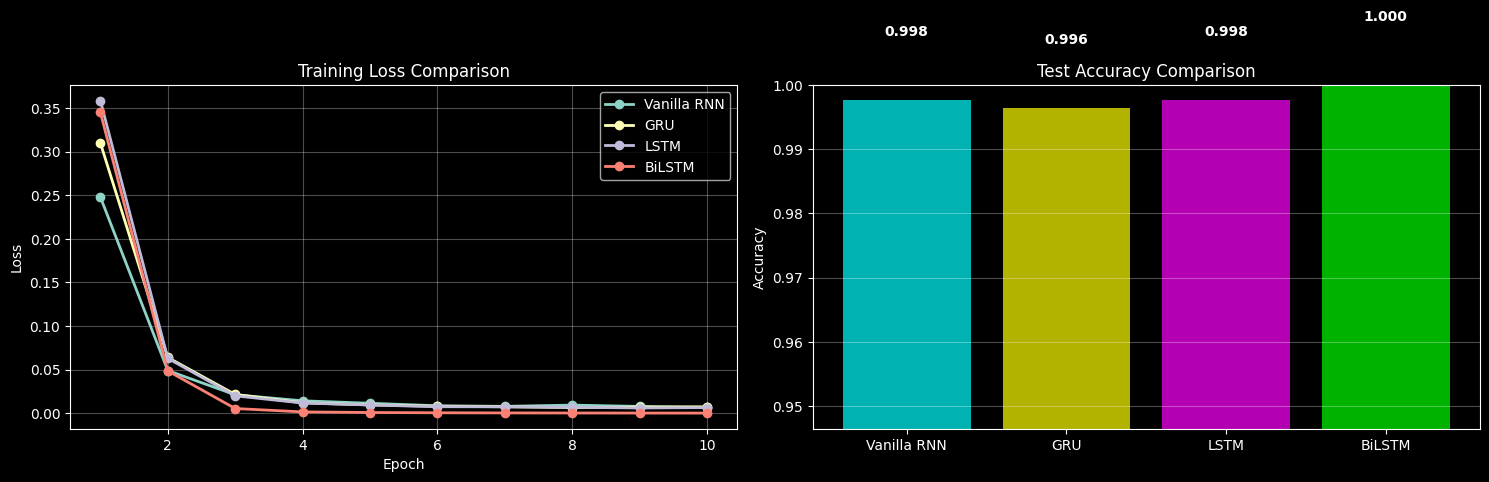

RESULTS SUMMARY
Vanilla RNN     Accuracy: 0.9977
GRU             Accuracy: 0.9965
LSTM            Accuracy: 0.9977
BiLSTM          Accuracy: 1.0000


In [19]:
# Compare all models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
# Epochs vs Losses
for name, data in results.items(): # loop on 4 models and plot Epochs vs Losses for each one
    ax1.plot(range(1, EPOCHS+1), data['losses'], marker='o', label=name, linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(alpha=0.3)

models = list(results.keys())
accuracies = [results[m]['accuracy'] for m in models]
colors = ['cyan', 'yellow', 'magenta', 'lime']
ax2.bar(models, accuracies, color=colors, alpha=0.7)
ax2.set_ylabel('Accuracy')
ax2.set_title('Test Accuracy Comparison')
ax2.set_ylim([min(accuracies) - 0.05, 1.0])
ax2.grid(alpha=0.3, axis='y')

for i, v in enumerate(accuracies):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("="*60)
print("RESULTS SUMMARY")
print("="*60)
for name, data in results.items():
    print(f"{name:15s} Accuracy: {data['accuracy']:.4f}")
print("="*60)

---

## Now let's test the best model (BiLSTM) with your own sentences!


In [20]:
def predict_food_entities(sentence, model, vocab):
    """
    Predict food entities in a custom sentence.

    Args:
        sentence: String sentence to analyze
        model: Trained BiLSTM model
        vocab: Vocabulary dictionary

    Returns:
        List of (word, is_food, confidence) tuples
    """
    model.eval()

    # Tokenize
    words = sentence.lower().split() # convert sentence to list of words
    word_ids = [vocab.get(word, vocab['<UNK>']) for word in words] # Convert words to IDs e.g. [1, 2, 3]

    # Convert to tensor
    input_tensor = torch.tensor([word_ids], dtype=torch.long).to(device)

    # Predict
    with torch.no_grad():
        predictions = model(input_tensor)  # (1, seq_len, 2) e.g. if each sentence has 3 words[1, 3, 2]
        probabilities = torch.softmax(predictions[0], dim=1)  # (seq_len, 2)  -- [0] because it's [[[]]] - so we need it 2d [[]]
        predicted_labels = torch.argmax(probabilities, dim=1).cpu().numpy()
        confidences = probabilities[:, 1].cpu().numpy()  # Confidence for "food" class -- We want the confidence that each word IS food, so we take column 1!

    # Format results
    results = []
    for word, label, conf in zip(words, predicted_labels, confidences):
        results.append((word, bool(label), float(conf)))

    return results


def display_food_predictions(sentence, results):
    """Display predictions in a nice format"""
    print(f"\nSentence: {sentence}")
    print("="*60)
    print(f"{'Word':<15} {'Is Food?':<15} {'Confidence':<12}")
    print("-"*60)

    for word, is_food, conf in results:
        label = "FOOD" if is_food else "NOT FOOD"
        color = '\033[92m' if is_food else '\033[91m'  # Green for food, red for not .. don't worry about that this is just for nice visualization
        reset = '\033[0m'
        print(f"{word:<15} {color}{label:<15}{reset} {conf:>6.2%}")

    # Summary
    food_words = [word for word, is_food, _ in results if is_food]
    if food_words:
        print(f"\nFood items detected: {', '.join(food_words)}")
    else:
        print(f"\nNo food items detected")


print("testing functions ready!")

testing functions ready!


```py
# Without softmax:
predictions = [
    [2.5, 0.8],   # word "i"
    [3.1, 1.2],   # word "love"
    [0.5, 4.7]    # word "pizza"
]
"pizza" → [0.5, 4.7]  # What does 4.7 mean? 🤔

# With softmax:
probabilities = torch.softmax(predictions, dim=1)
probabilities = [
    [0.92, 0.08],  # word "i": 92% not_food, 8% food
    [0.87, 0.13],  # word "love": 87% not_food, 13% food
    [0.11, 0.89]   # word "pizza": 11% not_food, 89% food
]
"pizza" → [0.11, 0.89]  # 89% confident it's food! ✓
# Benefits: All values between 0 and 1 ✓ & Each row sums to 1 ✓
```
```py
#Softmax vs Sigmoid:
# Sigmoid: Binary classification (1 output)
score = 2.5
sigmoid(2.5) = 0.92  # Single value between 0-1
# Used when you have 1 class (yes/no)

# Softmax: Multi-class classification (multiple outputs)
scores = [2.5, 0.8]
softmax([2.5, 0.8]) = [0.92, 0.08]  # Multiple values, sum to 1
# Used when you have 2+ classes (food vs not_food)

In [21]:
# Test the BiLSTM model with custom sentences!

test_sentences_food = [
    "I love eating grilled salmon with rice",
    "The chicken crossed the road yesterday",
    "She drinks coffee every morning",
    "The coffee table is made of wood",
    "I bought fresh strawberries and milk",
    "She has strawberry blonde hair",
    "The chef prepared delicious pasta with tomato sauce",
    "The pepper spray was very effective",
]


for sentence in test_sentences_food:
    results = predict_food_entities(sentence, bilstm_model, vocab)
    display_food_predictions(sentence, results)
    print()


Sentence: I love eating grilled salmon with rice
Word            Is Food?        Confidence  
------------------------------------------------------------
i               NOT FOOD         0.00%
love            NOT FOOD         0.00%
eating          NOT FOOD         0.01%
grilled         NOT FOOD         0.53%
salmon          FOOD            100.00%
with            NOT FOOD         0.00%
rice            FOOD            99.43%

Food items detected: salmon, rice


Sentence: The chicken crossed the road yesterday
Word            Is Food?        Confidence  
------------------------------------------------------------
the             NOT FOOD         0.00%
chicken         NOT FOOD         0.15%
crossed         NOT FOOD         0.01%
the             NOT FOOD         0.00%
road            NOT FOOD         0.00%
yesterday       NOT FOOD         0.00%

No food items detected


Sentence: She drinks coffee every morning
Word            Is Food?        Confidence  
-------------------------------

In [22]:
# Try your own sentences!
print("\n" + "="*60)
print("TEST YOUR OWN SENTENCES")
print("="*60)

# Add your custom sentences here:
my_sentences = [
    "I grilled some beef and vegetables",
    "The turkey is walking in the garden",
    "Youssuf played with his pet duck yesterday in the garden, they had nice time!",
    "The checken hit the dog",
    "This task is a piece of cake",
    "She spilled the beans during the meeting"
    # Add more sentences to test!
]

for sentence in my_sentences:
    results = predict_food_entities(sentence, bilstm_model, vocab)
    display_food_predictions(sentence, results)
    print()


TEST YOUR OWN SENTENCES

Sentence: I grilled some beef and vegetables
Word            Is Food?        Confidence  
------------------------------------------------------------
i               NOT FOOD         0.00%
grilled         NOT FOOD         0.50%
some            NOT FOOD         0.01%
beef            FOOD            100.00%
and             NOT FOOD         0.12%
vegetables      FOOD            97.99%

Food items detected: beef, vegetables


Sentence: The turkey is walking in the garden
Word            Is Food?        Confidence  
------------------------------------------------------------
the             NOT FOOD         0.00%
turkey          NOT FOOD         0.05%
is              NOT FOOD         0.00%
walking         NOT FOOD         5.73%
in              NOT FOOD         0.00%
the             NOT FOOD         0.00%
garden          NOT FOOD         0.08%

No food items detected


Sentence: Youssuf played with his pet duck yesterday in the garden, they had nice time!
Word    

---

<div dir="rtl" style="text-align: right; font-size: 22px; font-weight: bold; background-color: #8b0000; padding: 15px; border-radius: 10px;">

# Part 2: Many-to-One (SMS Spam Classification) - PRACTICE

</div>

**Now it's YOUR turn!**

**Task:** Classify SMS messages as **spam** (1) or **not spam** (0)

**Dataset:** SMS Spam Collection (5574 real text messages)

**What you need to do:**

1. Build vocabulary from SMS dataset
2. Create SpamDataset class (many-to-one, like sentiment anlaysis problems)
3. Adapt 4 RNN models for binary classification
4. Train all models and compare
5. Visualize results

**Hints:**

- Use the same structure as Food NER but change to many-to-one
- For many-to-one: Use final hidden state (not all outputs)
- GloVe embeddings are already loaded!
- Follow the patterns from the Food NER example above

## Load SMS Spam Dataset


In [23]:
# Load SMS Spam dataset
print('Loading SMS Spam dataset...')
sms_data = load_dataset('sms_spam', split='train')

# Shuffle and split
sms_data = sms_data.shuffle(seed=42)
split_idx = int(0.8 * len(sms_data))

train_sms = sms_data.select(range(split_idx))
test_sms = sms_data.select(range(split_idx, len(sms_data)))

print(f'\nDataset: SMS Spam Collection')
print(f'Train: {len(train_sms)} messages')
print(f'Test: {len(test_sms)} messages')
print(f'\nClasses: 0=Not Spam, 1=Spam')

print(f'\nSample messages:')
print(f'Message: {train_sms[0]["sms"]}')
print(f'Label: {train_sms[0]["label"]}')
print(f'\nMessage: {train_sms[10]["sms"]}')
print(f'Label: {train_sms[10]["label"]}')

Loading SMS Spam dataset...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/359k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5574 [00:00<?, ? examples/s]


Dataset: SMS Spam Collection
Train: 4459 messages
Test: 1115 messages

Classes: 0=Not Spam, 1=Spam

Sample messages:
Message: sports fans - get the latest sports news str* 2 ur mobile 1 wk FREE PLUS a FREE TONE Txt SPORT ON to 8007 www.getzed.co.uk 0870141701216+ norm 4txt/120p 

Label: 1

Message: Cramps stopped. Going back to sleep

Label: 0


In [24]:
import pandas as pd
pd.DataFrame(train_sms)

,sms,label
0,sports fans - get the latest sports news str* ...,1
1,It's justbeen overa week since we broke up and...,0
2,Not directly behind... Abt 4 rows behind ü...\n,0
3,"Haha, my legs and neck are killing me and my a...",0
4,Me too baby! I promise to treat you well! I be...,0
...,...,...
4454,PRIVATE! Your 2004 Account Statement for 07849...,1
4455,"""HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAR...",0
4456,True. Its easier with her here.\n,0
4457,Come to my home for one last time i wont do an...,0


## TODO 1: Build Vocabulary for SMS Data

Create a vocabulary dictionary from the SMS training data.

**Requirements:**

- Include `<PAD>` and `<UNK>` tokens
- Add words appearing at least 2 times
- Store result in `sms_vocab` dictionary

**Hint:** Follow the same pattern as Food NER vocabulary building!


In [25]:
counter = Counter()
for message in train_sms:
  words = message['sms'].lower().split() # list
  counter.update(words)

sms_vocab = {'<PAD>': 0, '<UNK>': 1}
for word, count in counter.items():
  if count >=2 and word not in sms_vocab:
    sms_vocab[word] = len(sms_vocab)
print(len(sms_vocab))
print(list(sms_vocab.items())[:10])

4754
[('<PAD>', 0), ('<UNK>', 1), ('sports', 2), ('-', 3), ('get', 4), ('the', 5), ('latest', 6), ('news', 7), ('2', 8), ('ur', 9)]


In [26]:
# TODO: Build vocabulary from SMS training data
# YOUR CODE HERE
# Step 1: Count word frequencies
word_counts = Counter()
for message in train_sms:
    words = message['sms'].lower().split() # List of words
    word_counts.update(words)

# Step 2: Build vocabulary with special tokens and frequency threshold
sms_vocab = {'<PAD>': 0, '<UNK>': 1}
for word, count in word_counts.items():
    if count >= 2 and word not in sms_vocab:  # Only include words appearing at least 2 times
        sms_vocab[word] = len(sms_vocab)

print(f'SMS Vocabulary size: {len(sms_vocab)}')
print(f'Sample vocab: {list(sms_vocab.items())[:10]}')

SMS Vocabulary size: 4754
Sample vocab: [('<PAD>', 0), ('<UNK>', 1), ('sports', 2), ('-', 3), ('get', 4), ('the', 5), ('latest', 6), ('news', 7), ('2', 8), ('ur', 9)]


In [27]:
# HIDDEN TESTS for vocabulary

In [28]:
# Create SMS embedding matrix (using same GloVe vectors)
sms_embedding_matrix = np.random.randn(len(sms_vocab), EMBEDDING_DIM).astype('float32') * 0.01
sms_embedding_matrix[sms_vocab['<PAD>']] = np.zeros(EMBEDDING_DIM)
found_count_sms = 0
for word, idx in sms_vocab.items():
    if word in glove_vectors:
        sms_embedding_matrix[idx] = glove_vectors[word]
        found_count_sms += 1

print(f'SMS Embedding matrix shape: {sms_embedding_matrix.shape}')
print(f'Found GloVe vectors for {found_count_sms}/{len(sms_vocab)} words ({100*found_count_sms/len(sms_vocab):.1f}%)')

SMS Embedding matrix shape: (4754, 100)
Found GloVe vectors for 2831/4754 words (59.5%)


## TODO 2: Create SpamDataset Class

Create a PyTorch Dataset class for SMS spam classification.

**Requirements:**

- Inherit from `torch.utils.data.Dataset`
- Implement `__init__`, `__len__`, `__getitem__`
- Convert SMS text to word IDs
- Return (text_tensor, label_tensor)
- This is **many-to-one** (entire message → single label)

**Hint:** Very similar to FoodNERDataset but labels are scalars, not sequences!


In [29]:
# TODO: Create SpamDataset class
# Your code here:

# YOUR CODE HERE
class SpamDataset(Dataset):
    def __init__(self, data, vocab):
        self.data = data
        self.vocab = vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # # Get message and label
        message = self.data[idx]['sms']  # Get the message text
        label = self.data[idx]['label']  # -> Scalar 0 or 1 not a list like NER because it's Many-to-one (message→label)

        # Tokenize and convert to IDs
        words = message.lower().split()
        word_ids = [self.vocab.get(word, self.vocab['<UNK>']) for word in words]
        return torch.tensor(word_ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)

# Collate function for spam data
def spam_collate_fn(batch):
    texts, labels = zip(*batch)
    lengths = torch.tensor([len(t) for t in texts])
    padded_texts = pad_sequence(texts, batch_first=True, padding_value=sms_vocab['<PAD>'])
    labels = torch.tensor(labels, dtype=torch.long)
    return padded_texts, labels, lengths


# Create datasets
train_spam_dataset = SpamDataset(train_sms, sms_vocab)
test_spam_dataset = SpamDataset(test_sms, sms_vocab)

train_spam_loader = DataLoader(train_spam_dataset, batch_size=32, shuffle=True, collate_fn=spam_collate_fn)
test_spam_loader = DataLoader(test_spam_dataset, batch_size=32, shuffle=False, collate_fn=spam_collate_fn)

print(f'Train batches: {len(train_spam_loader)}')
print(f'Test batches: {len(test_spam_loader)}')

Train batches: 140
Test batches: 35


In [30]:
# HIDDEN TESTS for SpamDataset

## TODO 3: Implement 4 RNN Models for Spam Classification

Adapt the 4 RNN models for **binary spam classification (many-to-one)**.

**Key differences from Food NER:**

- Use **final hidden state** (not all outputs)
- Output dimension = 2 (spam vs not-spam)
- For BiLSTM: Concatenate forward and backward final hidden states

**Models to implement:**

1. VanillaRNNSpam
2. GRUSpam
3. LSTMSpam
4. BiLSTMSpam

**Hint:** Use `pack_padded_sequence` and extract final hidden states!


In [31]:
# TODO: Implement 4 RNN models for spam classification
# Your code here:

# YOUR CODE HERE
# TODO 3: Implement 4 RNN Models for Spam Classification

from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

# Model 1: Vanilla RNN for Spam
class VanillaRNNSpam(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, embedding_matrix):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))     # Converts word IDs → word vectors (using GloVe)

        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, lengths):
        embedded = self.embedding(x)  # [batch, seq_len, emb_dim]

        # Pack sequences --> needs to know the real length of each message to remove padding.
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False) # RNN processes packed (no padding)

        # RNN
        _, hidden = self.rnn(packed)  # hidden: [1, batch, hidden_dim]
        hidden = hidden.squeeze(0)  # [batch, hidden_dim]

        # Classify
        output = self.fc(hidden)  # [batch, 2]
        return output


# Model 2: GRU for Spam
class GRUSpam(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, embedding_matrix):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, lengths):
        embedded = self.embedding(x)  # [batch, seq_len, emb_dim]

        # Pack sequences
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)

        # GRU
        _, hidden = self.gru(packed)  # hidden: [1, batch, hidden_dim]
        hidden = hidden.squeeze(0)  # [batch, hidden_dim]

        # Classify
        output = self.fc(hidden)  # [batch, 2]
        return output


# Model 3: LSTM for Spam
class LSTMSpam(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, embedding_matrix):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, lengths):
        embedded = self.embedding(x)  # [batch, seq_len, emb_dim]

        # Pack sequences
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)

        # LSTM
        _, (hidden, cell) = self.lstm(packed)  # hidden: [1, batch, hidden_dim]
        hidden = hidden.squeeze(0)  # [batch, hidden_dim]

        # Classify
        output = self.fc(hidden)  # [batch, 2]
        return output


# Model 4: BiLSTM for Spam
class BiLSTMSpam(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, embedding_matrix):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)  # *2 because bidirectional

    def forward(self, x, lengths):
        embedded = self.embedding(x)  # [batch, seq_len, emb_dim]

        # Pack sequences
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)

        # BiLSTM
        _, (hidden, cell) = self.lstm(packed)  # hidden: [2, batch, hidden_dim]

        # Concatenate forward and backward final hidden states
        forward_hidden = hidden[0]   # [batch, hidden_dim]
        backward_hidden = hidden[1]  # [batch, hidden_dim]
        combined = torch.cat([forward_hidden, backward_hidden], dim=1)  # [batch, hidden_dim*2]

        # Classify
        output = self.fc(combined)  # [batch, 2]
        return output
print('All 4 spam classification models defined!')

All 4 spam classification models defined!


Forward Pass (Example)
```python
# Input
x = [[5, 12, 89, 3, 0, 0]]  # 1 message: "win free prize now <PAD> <PAD>"
lengths = [4]  # Actual length is 4 words
```
```python
# Step 1: Embedding
embedded = self.embedding(x)  # [1, 6, 100]
# Converts IDs → vectors
# Example:
[5, 12, 89, 3, 0, 0]
    ↓
[
  [0.2, 0.5, ...],  # "win" vector (100-dim)
  [0.8, 0.1, ...],  # "free" vector
  [0.3, 0.9, ...],  # "prize" vector
  [0.1, 0.4, ...],  # "now" vector
  [0.0, 0.0, ...],  # <PAD> (all zeros)
  [0.0, 0.0, ...]   # <PAD> (all zeros)
]  # Shape: [1, 6, 100]
```
```python
# Step 2: Pack (skip details as you said)
packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
# Just removes padding for efficiency
# RNN only processes 4 real words, not 6
```
```python
# Step 3: RNN
_, hidden = self.rnn(packed)
# RNN processes word by word:
h1 = RNN(word_"win")
h2 = RNN(word_"free", h1)     # Uses previous hidden state
h3 = RNN(word_"prize", h2)    # Uses previous hidden state  
h4 = RNN(word_"now", h3)      # Uses previous hidden state
# ↑ This is the final hidden state (has full message context!)
hidden = h4  # Shape: [1, 1, 128]

# *Why we use `_` for output?**
_, hidden = self.rnn(packed)
#↑
# We DON'T need all outputs (h1, h2, h3, h4)
# We ONLY need the final hidden state (h4)
```
```python
# Step 4: Squeeze
hidden = hidden.squeeze(0)  # [1, 128]
# Remove the extra dimension: [1, 1, 128] → [1, 128]
```
```python
# Step 5: Classify
output = self.fc(hidden)  # [1, 2] # Final hidden state → 2 scores: [not_spam_score, spam_score]
# Example:
hidden = [0.5, 0.8, -0.2, ...]  # 128 numbers (message summary)
    ↓
output = [0.3, 2.5]  # [not_spam_score, spam_score]
    ↓ argmax
predicted = 1  # SPAM!
```
Key Concept: Many-to-One
```
Input:  "win"  "free"  "prize"  "now"
         ↓       ↓       ↓        ↓
RNN:    h1  →  h2   →   h3   →   h4 (final hidden)
                                  ↓
                                 fc
                                  ↓
Output:                      [not_spam, spam]
                             ONE prediction for ENTIRE message
```
Compare to Food NER (Many-to-Many):
```
Input:  "I"    "love"  "pizza"
         ↓       ↓       ↓
RNN:    h1  →  h2   →   h3
         ↓       ↓       ↓
        fc      fc      fc
         ↓       ↓       ↓
Output: [0,1]  [0,1]   [0,1]  ← Prediction for EACH word
```
```
# Without packing (Food NER):
Message: "win free prize <PAD> <PAD>"
         [5, 12, 89, 0, 0]

RNN processes ALL 5 positions:
RNN: word1 → word2 → word3 → PAD → PAD
     ✓       ✓       ✓       ✗     ✗
                              ↑ waste of computation!
# With packing (Spam):
pythonMessage: "win free prize <PAD> <PAD>"
         [5, 12, 89, 0, 0]
lengths = 3  # Tell model: only 3 real words

pack_padded_sequence removes padding:
[5, 12, 89, 0, 0] + length=3 → [5, 12, 89]

RNN processes ONLY 3 positions:
RNN: word1 → word2 → word3
     ✓       ✓       ✓
                         ✓ No wasted computation!


In [32]:
# HIDDEN TESTS for spam models

## Training and Evaluation Functions



In [33]:
def train_spam_model(model, train_loader, epochs=10, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0  # for all batches / one epoch
        for texts, labels, lengths in train_loader: # DataLoader with 36 batches
            texts, labels = texts.to(device), labels.to(device)
            optimizer.zero_grad()
            predictions = model(texts, lengths)  # pass lengths so pack_padded_sequence knows where the real message ends and padding begins, making RNN skip the padding!
            loss = criterion(predictions, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)  # for each epoch
        losses.append(avg_loss)
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')
    return losses


def evaluate_spam_model(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for texts, labels, lengths in test_loader:
            texts = texts.to(device)
            predictions = model(texts, lengths)
            predicted_labels = torch.argmax(predictions, dim=1).cpu().numpy()
            all_preds.extend(predicted_labels)
            all_labels.extend(labels.numpy())
    accuracy = accuracy_score(all_labels, all_preds)
    return accuracy


print('Training functions ready!')

Training functions ready!


## Train All 4 Spam Models

Now train all 4 models and compare their performance!


In [35]:
# Train all 4 spam models
SPAM_HIDDEN_DIM = 128
SPAM_EPOCHS = 10
SPAM_LR = 0.001

spam_results = {}

# Vanilla RNN
print('='*60)
print('Training Vanilla RNN for Spam...')
print('='*60)
rnn_spam = VanillaRNNSpam(len(sms_vocab), EMBEDDING_DIM, SPAM_HIDDEN_DIM,2, sms_embedding_matrix)
rnn_spam_losses = train_spam_model(rnn_spam, train_spam_loader, epochs=SPAM_EPOCHS, lr=SPAM_LR)
rnn_spam_acc = evaluate_spam_model(rnn_spam, test_spam_loader)
spam_results['Vanilla RNN'] = {'losses': rnn_spam_losses, 'accuracy': rnn_spam_acc}
print(f'\nVanilla RNN Spam Accuracy: {rnn_spam_acc:.4f}\n')

# GRU
print('='*60)
print('Training GRU for Spam...')
print('='*60)
gru_spam = GRUSpam(len(sms_vocab), EMBEDDING_DIM, SPAM_HIDDEN_DIM,2, sms_embedding_matrix)
gru_spam_losses = train_spam_model(gru_spam, train_spam_loader, epochs=SPAM_EPOCHS, lr=SPAM_LR)
gru_spam_acc = evaluate_spam_model(gru_spam, test_spam_loader)
spam_results['GRU'] = {'losses': gru_spam_losses, 'accuracy': gru_spam_acc}
print(f'\nGRU Spam Accuracy: {gru_spam_acc:.4f}\n')

# LSTM
print('='*60)
print('Training LSTM for Spam...')
print('='*60)
lstm_spam = LSTMSpam(len(sms_vocab), EMBEDDING_DIM, SPAM_HIDDEN_DIM,2, sms_embedding_matrix)
lstm_spam_losses = train_spam_model(lstm_spam, train_spam_loader, epochs=SPAM_EPOCHS, lr=SPAM_LR)
lstm_spam_acc = evaluate_spam_model(lstm_spam, test_spam_loader)
spam_results['LSTM'] = {'losses': lstm_spam_losses, 'accuracy': lstm_spam_acc}
print(f'\nLSTM Spam Accuracy: {lstm_spam_acc:.4f}\n')

# BiLSTM
print('='*60)
print('Training BiLSTM for Spam...')
print('='*60)
bilstm_spam = BiLSTMSpam(len(sms_vocab), EMBEDDING_DIM, SPAM_HIDDEN_DIM,2, sms_embedding_matrix)
bilstm_spam_losses = train_spam_model(bilstm_spam, train_spam_loader, epochs=SPAM_EPOCHS, lr=SPAM_LR)
bilstm_spam_acc = evaluate_spam_model(bilstm_spam, test_spam_loader)
spam_results['BiLSTM'] = {'losses': bilstm_spam_losses, 'accuracy': bilstm_spam_acc}
print(f'\nBiLSTM Spam Accuracy: {bilstm_spam_acc:.4f}\n')

Training Vanilla RNN for Spam...
Epoch 1/10, Loss: 0.1949
Epoch 2/10, Loss: 0.1066
Epoch 3/10, Loss: 0.0676
Epoch 4/10, Loss: 0.0419
Epoch 5/10, Loss: 0.0260
Epoch 6/10, Loss: 0.0286
Epoch 7/10, Loss: 0.0160
Epoch 8/10, Loss: 0.0126
Epoch 9/10, Loss: 0.0071
Epoch 10/10, Loss: 0.0037

Vanilla RNN Spam Accuracy: 0.9767

Training GRU for Spam...
Epoch 1/10, Loss: 0.1993
Epoch 2/10, Loss: 0.0696
Epoch 3/10, Loss: 0.0397
Epoch 4/10, Loss: 0.0214
Epoch 5/10, Loss: 0.0109
Epoch 6/10, Loss: 0.0068
Epoch 7/10, Loss: 0.0072
Epoch 8/10, Loss: 0.0024
Epoch 9/10, Loss: 0.0018
Epoch 10/10, Loss: 0.0013

GRU Spam Accuracy: 0.9910

Training LSTM for Spam...
Epoch 1/10, Loss: 0.2178
Epoch 2/10, Loss: 0.0778
Epoch 3/10, Loss: 0.0477
Epoch 4/10, Loss: 0.0302
Epoch 5/10, Loss: 0.0193
Epoch 6/10, Loss: 0.0113
Epoch 7/10, Loss: 0.0178
Epoch 8/10, Loss: 0.0070
Epoch 9/10, Loss: 0.0051
Epoch 10/10, Loss: 0.0037

LSTM Spam Accuracy: 0.9901

Training BiLSTM for Spam...
Epoch 1/10, Loss: 0.1968
Epoch 2/10, Loss:

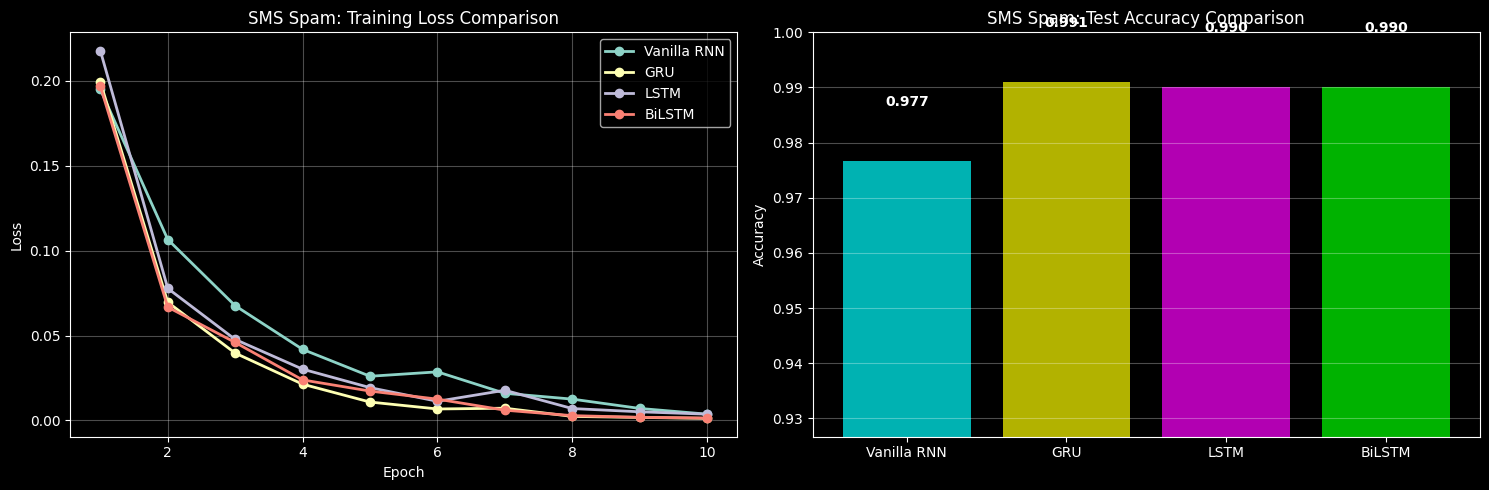

SMS SPAM RESULTS SUMMARY
Vanilla RNN     Accuracy: 0.9767
GRU             Accuracy: 0.9910
LSTM            Accuracy: 0.9901
BiLSTM          Accuracy: 0.9901


In [36]:
# Visualize spam results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Training losses
for name, data in spam_results.items():
    ax1.plot(range(1, SPAM_EPOCHS+1), data['losses'], marker='o', label=name, linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('SMS Spam: Training Loss Comparison')
ax1.legend()
ax1.grid(alpha=0.3)

# Test accuracies
models = list(spam_results.keys())
accuracies = [spam_results[m]['accuracy'] for m in models]
colors = ['cyan', 'yellow', 'magenta', 'lime']
ax2.bar(models, accuracies, color=colors, alpha=0.7)
ax2.set_ylabel('Accuracy')
ax2.set_title('SMS Spam: Test Accuracy Comparison')
ax2.set_ylim([min(accuracies) - 0.05, 1.0])
ax2.grid(alpha=0.3, axis='y')
for i, v in enumerate(accuracies):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('='*60)
print('SMS SPAM RESULTS SUMMARY')
print('='*60)
for name, data in spam_results.items():
    print(f"{name:15s} Accuracy: {data['accuracy']:.4f}")
print('='*60)

---

<div dir="rtl" style="text-align: right; font-size: 24px; font-weight: bold; background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 20px; border-radius: 10px;">

مبروك! خلصت Week 8 بنجاح والحمد لله

</div>


**What We Built This Week:**

1. Many-to-many sequence labeling (Food NER)
2. Many-to-one sequence classification (SMS Spam)
3. 8 total models (4 for each task)
4. Complete training and evaluation pipeline

**Next:** Week 9 covers Attention mechanisms and Transformers!

